In [35]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

In [36]:
import os
# Create charts folder if it does not exist
os.makedirs("charts", exist_ok=True)

In [37]:
# Load the Titanic dataset (Load only once)
df = sns.load_dataset("titanic")

# Save offline copy of the dataset
df.to_csv("titanic.csv", index=False)
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [38]:
#Display first five records
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [39]:
df.shape

(891, 15)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [41]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [42]:
#Missing value percentage
missing_percentage = (df.isnull().sum()/len(df))*100
missing_percentage = missing_percentage[missing_percentage>0].sort_values(ascending=False)

print("Missing value percentage:")
print(missing_percentage)

Missing value percentage:
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [43]:
#create a copy of the dataset for cleaning
clean_df = df.copy()
#Drop rows where 'embarked' has missing values (<5%)
clean_df = clean_df.dropna(subset=['embarked'])
#fill missing 'age' values with the median (5%-30%)
clean_df["age"] = clean_df["age"].fillna(clean_df["age"].median())
#fill missing 'embark_town' values with the mode(same patter as embarked)
clean_df["embark_town"] = clean_df["embark_town"].fillna(clean_df["embark_town"].mode()[0])

#Drop the 'deck' column because it has a very high percentage of missing values
clean_df = clean_df.drop(columns=['deck'])

print("Missing vakues after cleaning:")
print(clean_df.isnull().sum())

Missing vakues after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [44]:
#compare dataset size before and after cleaning
print("Original Shape: ", df.shape)
print("Cleaned Shape: ", clean_df.shape)

Original Shape:  (891, 15)
Cleaned Shape:  (889, 14)


# **Univariate Analysis**

This section analyzes the distribution of Age and Fare using histograms,
box plots, IQR outlier detection, and summary statistics.

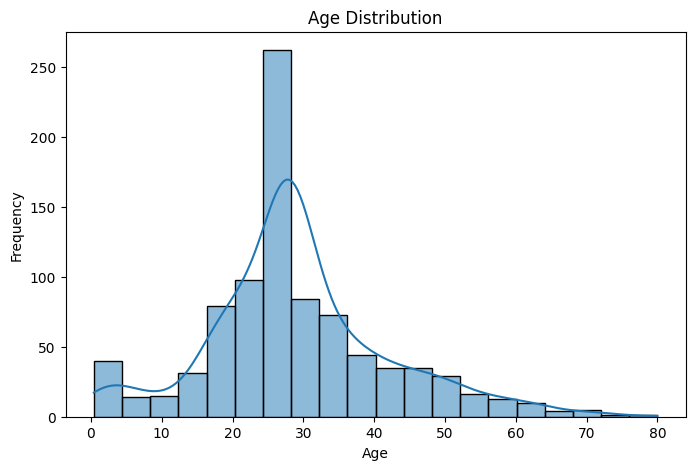

In [45]:
#Display the age distribution
plt.figure(figsize=(8,5))
sns.histplot(clean_df["age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
# Save the chart
plt.savefig(
    "charts/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

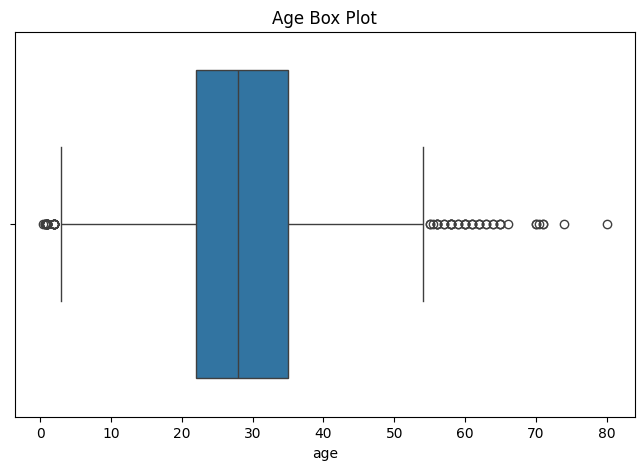

In [46]:
#Identify age outlier
plt.figure(figsize=(8,5))
sns.boxplot(x=clean_df["age"])

plt.title("Age Box Plot")
# Save the chart
plt.savefig(
    "charts/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

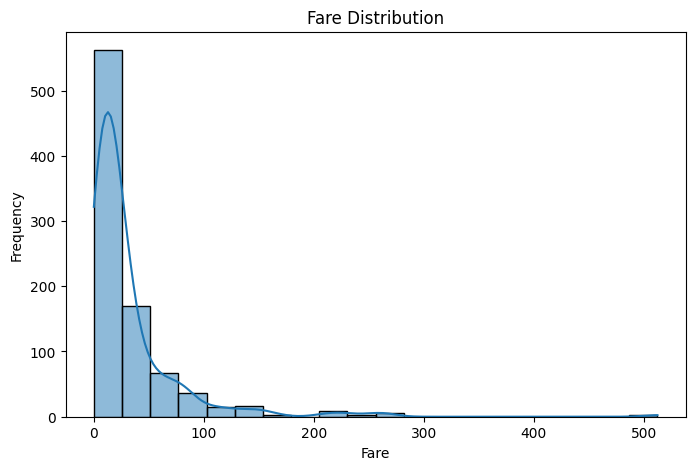

In [47]:
#Display the fare distribution
plt.figure(figsize=(8,5))
sns.histplot(clean_df["fare"], bins=20, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
# Save the chart
plt.savefig(
    "charts/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

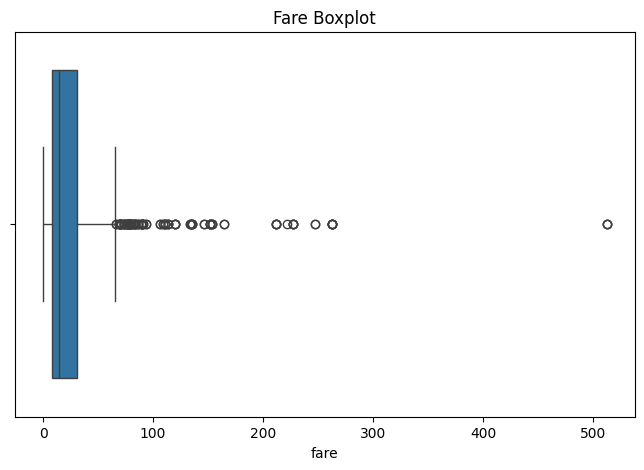

In [48]:
#Identify fare outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=clean_df["fare"])

plt.title("Fare Boxplot")
# Save the chart
plt.savefig(
    "charts/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [49]:
#function to calculate IQR outliers
def count_outliers(column):
  q1 = clean_df[column].quantile(0.25)
  q3 = clean_df[column].quantile(0.75)
  iqr = q3-q1

  lower_limit = q1 - (1.5*iqr)
  upper_limit = q3 + (1.5*iqr)

  outliers = clean_df[
      (clean_df[column] < lower_limit) | (clean_df[column] > upper_limit)
  ]
  return len(outliers)

print("Age outliers: ", count_outliers("age"))
print("Fare outliers: ", count_outliers("fare"))


Age outliers:  65
Fare outliers:  114


In [50]:
fare_mean = clean_df["fare"].mean()
fare_median = clean_df["fare"].median()
fare_mode = clean_df["fare"].mode()[0]

print("Mean: ",fare_mean)
print("Median: ",fare_median)
print("Mode: ",fare_mode)

Mean:  32.09668087739032
Median:  14.4542
Mode:  8.05


In [51]:
#Determine the distribution shape using mean, median and mode
if fare_mean > fare_median > fare_mode:
  print("Fare distribution is Right Skewed")
elif fare_mean < fare_median < fare_mode:
  print("Fare distribution is Left Skewed")
else:
  print("Fare distribution is Appoximately Symmetric")

Fare distribution is Right Skewed


## **Bivariate Analysis**

This section analyzes the relationship between passenger characteristics
and survival using group-wise analysis and correlation.

sex
female    74.038462
male      18.890815
Name: survived, dtype: float64


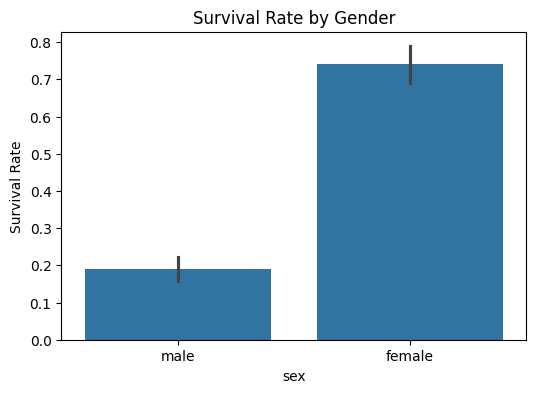

In [52]:
#calculate survival rate by gender
survival_by_sex = clean_df.groupby("sex")["survived"].mean()*100
print(survival_by_sex)

plt.figure(figsize=(6,4))
sns.barplot(data=clean_df, x="sex", y="survived")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")

plt.savefig(
    "charts/survival_by_sex.png",
     dpi=300,
     bbox_inches="tight"
)

plt.show()

pclass
1    62.616822
2    47.282609
3    24.236253
Name: survived, dtype: float64


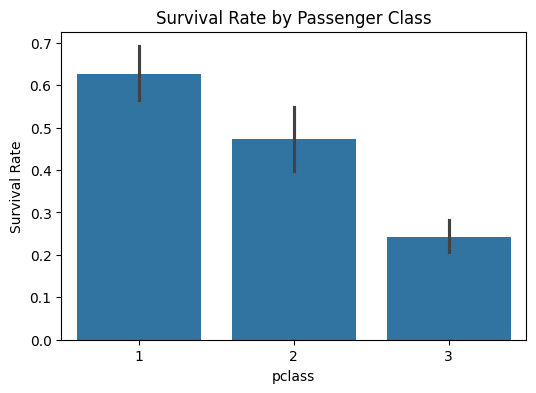

In [53]:
#calculate survival rate by passenger class
survival_by_class = clean_df.groupby("pclass")["survived"].mean()*100
print(survival_by_class)

plt.figure(figsize=(6,4))
sns.barplot(data=clean_df, x="pclass", y="survived")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")

plt.savefig(
    "charts/survival_by_class.png",
     dpi=300,
     bbox_inches="tight"
)

plt.show()

      sex  pclass  survived
0  female       1  0.967391
1  female       2  0.921053
2  female       3  0.500000
3    male       1  0.368852
4    male       2  0.157407
5    male       3  0.135447


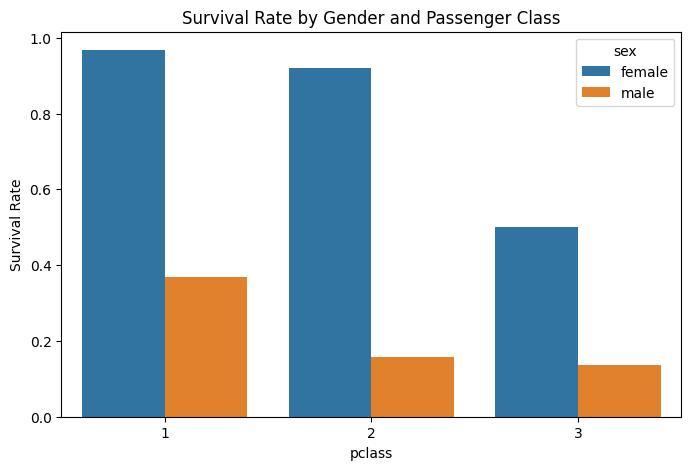

In [54]:
#calculate sruvival rate by gender and passenger class
survival_by_sex_class = (clean_df.groupby(["sex", "pclass"])["survived"].mean().reset_index())
print(survival_by_sex_class)

plt.figure(figsize=(8,5))
sns.barplot(data=survival_by_sex_class, x="pclass", y="survived", hue="sex")
plt.title("Survival Rate by Gender and Passenger Class")
plt.ylabel("Survival Rate")

plt.savefig(
    "charts/survival_by_sex_class.png",
     dpi=300,
     bbox_inches="tight"
)

plt.show()


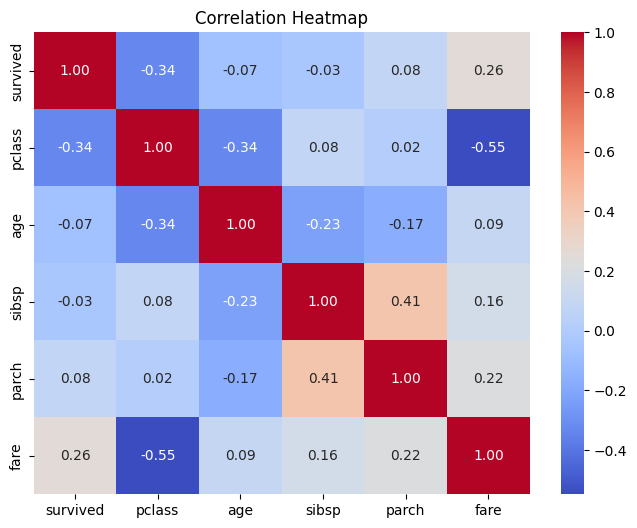

In [55]:
#select numeric columns for correlation analysis
correlation_columns = [
    "survived", "pclass",
    "age", "sibsp",
    "parch", "fare"
]
correlation_matrix = clean_df[correlation_columns].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

plt.savefig(
    "charts/correlation_heatmap.png",
     dpi=300,
     bbox_inches="tight"
)

plt.show()

In [56]:
#find the strongest correlation pairs
correlation_pairs = (correlation_matrix.unstack().sort_values(key=abs, ascending=False))

#Remove duplicate pairs and self-correlations
correlation_pairs = correlation_pairs[
    correlation_pairs.index.get_level_values(0) < correlation_pairs.index.get_level_values(1)
]

print("Top 2 strongest correlation")
print(correlation_pairs.head(2))

Top 2 strongest correlation
fare   pclass   -0.548193
parch  sibsp     0.414542
dtype: float64


## Interpretation

### 1. Fare and Passenger Class (-0.548)

The heatmap shows that passengers in first class paid more for their tickets, while passengers in third class paid less. This is why the correlation between fare and passenger class is negative.

### 2. Parents/Children and Siblings/Spouses (0.415)

The heatmap also shows a positive relationship between parents/children and siblings/spouses. This means passengers travelling with one family member were often travelling with other family members as well.


# 5. Multivariate Analysis

This section explores the relationship among multiple variables using
different visualizations and discusses feature scaling.

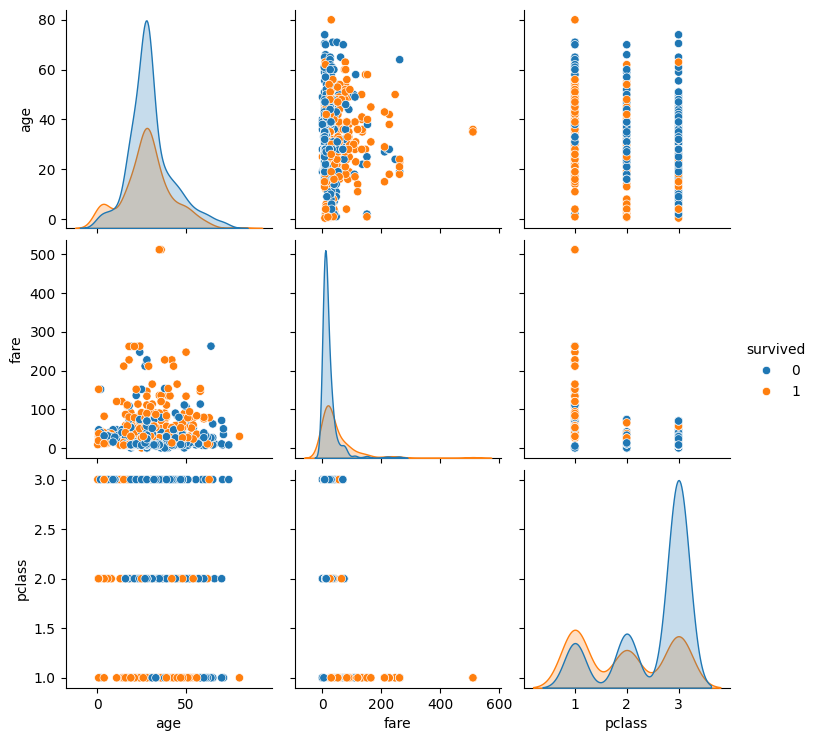

In [57]:
#select important features for multivariate analysis
pairplot_colums = ["survived", "age", "fare", "pclass"]
pairplot = sns.pairplot(clean_df[pairplot_colums], hue="survived")

pairplot.savefig("charts/pairplot.png", dpi=300)
plt.show()

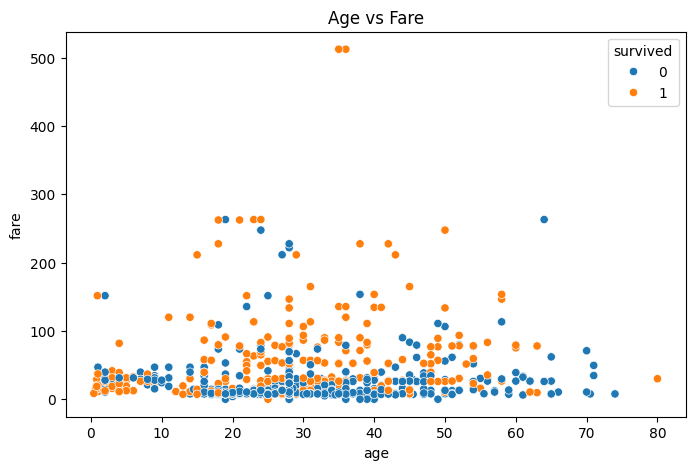

In [58]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=clean_df, x="age", y="fare", hue="survived")
plt.title("Age vs Fare")

plt.savefig(
    "charts/age_vs_fare.png",
     dpi=300,
     bbox_inches="tight"
)

plt.show()


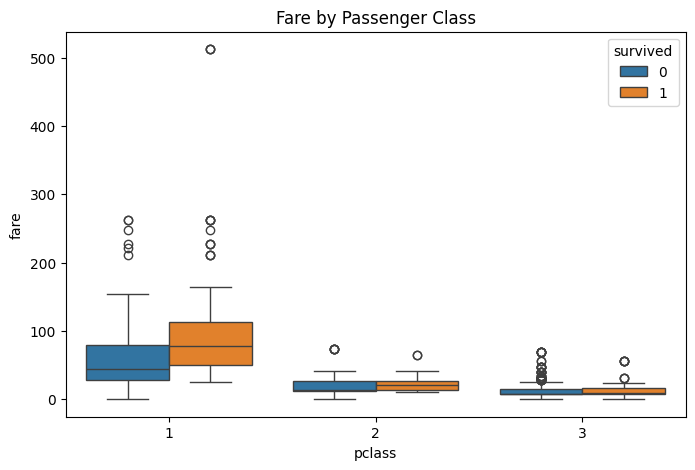

In [59]:
plt.figure(figsize=(8,5))
sns.boxplot(data=clean_df, x="pclass", y="fare", hue="survived")

plt.title("Fare by Passenger Class")
plt.savefig(
    "charts/fare_by_class.png",
     dpi=300,
     bbox_inches="tight"
)
plt.show()

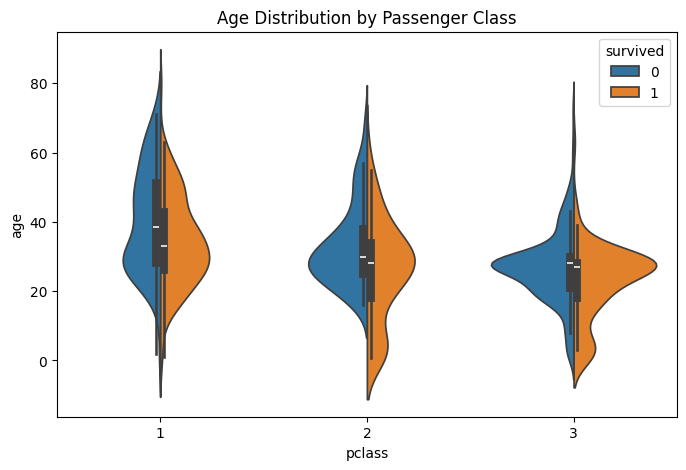

In [60]:
plt.figure(figsize=(8,5))
sns.violinplot(data=clean_df, x="pclass", y="age", hue="survived", split=True)

plt.title("Age Distribution by Passenger Class")
plt.savefig(
    "charts/age_by_class.png",
     dpi=300,
     bbox_inches="tight"
)
plt.show()

In [61]:
from sklearn.preprocessing import StandardScaler
#colums selected for scaling
scaling_columns = ["age", "fare"]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clean_df[scaling_columns])

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


## Interpretation

### Pairplot

The pairplot shows the relationships among Age, Fare, Passenger Class, and Survival.

### Scatter Plot

Passengers with higher ticket fares generally show a higher survival rate.

### Box Plot

First-class passengers paid higher fares than second- and third-class passengers.

### Violin Plot

The age distribution differs across passenger classes and survival groups.

### Standardization

Age and Fare have different scales. Standardization ensures that machine learning algorithms treat both features equally during model training.